# LEGO Brick Datasets – Basic Data Analysis

Two datasets from the **Bridge of Knowledge** platform (Gdańsk University of Technology):

| # | Name | URL |
|---|------|-----|
| 1 | Tagged images with LEGO bricks | https://mostwiedzy.pl/en/open-research-data/tagged-images-with-lego-bricks,202309140833448152311-0 |
| 2 | Tagged images with LEGO bricks – Part 2 | https://mostwiedzy.pl/en/open-research-data/tagged-images-with-lego-bricks-part-2,202309140835346842721-0 |

Both datasets contain real and rendered images of individual LEGO bricks with Pascal-VOC style XML bounding-box annotations.  
The **existing** `dataset_20210629145407_top_600` dataset is left untouched.

In [1]:
import os, zipfile, pathlib, xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import requests
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATA_DIR = pathlib.Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATASETS = {
    "tagged1": {
        "url":      "https://mostwiedzy.pl/en/open-research-data/"
                    "tagged-images-with-lego-bricks,202309140833448152311-0/download",
        "zip_name": "tagged1.zip",
        "dest_dir": DATA_DIR / "tagged1",
    },
    "tagged2": {
        "url":      "https://mostwiedzy.pl/en/open-research-data/"
                    "tagged-images-with-lego-bricks-part-2,202309140835346842721-0/download",
        "zip_name": "tagged2.zip",
        "dest_dir": DATA_DIR / "tagged2",
    },
}
print("Config ready.")

/Users/marco/repos/cas-deep-learning-cv-projekt/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config ready.


## 1 · Download & Extract Datasets

In [2]:
def download_and_extract(name: str, cfg: dict) -> None:
    zip_path = DATA_DIR / cfg["zip_name"]
    dest_dir = cfg["dest_dir"]

    # Download only if not yet present
    if not zip_path.exists():
        print(f"Downloading {name} …")
        resp = requests.get(cfg["url"], stream=True, allow_redirects=True)
        resp.raise_for_status()
        total = int(resp.headers.get("content-length", 0))
        with open(zip_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True,
                                              desc=cfg["zip_name"]) as bar:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                bar.update(len(chunk))
        print(f"  Saved → {zip_path}  ({zip_path.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"{name}: zip already present, skipping download.")

    # Extract only if destination folder is missing or empty
    if not dest_dir.exists() or not any(dest_dir.iterdir()):
        dest_dir.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {zip_path} → {dest_dir} …")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(dest_dir)
        print(f"  Done.")
    else:
        print(f"{name}: already extracted, skipping.")

for name, cfg in DATASETS.items():
    download_and_extract(name, cfg)
print("\nAll datasets ready.")

tagged1.zip: 100%|██████████| 6.02G/6.02G [03:19<00:00, 30.2MB/s]


  Saved → data/tagged1.zip  (6017.0 MB)
Extracting data/tagged1.zip → data/tagged1 …
  Done.


tagged2.zip: 100%|██████████| 2.27G/2.27G [01:17<00:00, 29.5MB/s]


  Saved → data/tagged2.zip  (2271.5 MB)
Extracting data/tagged2.zip → data/tagged2 …
  Done.

All datasets ready.


## 2 · Inspect Folder Structure

In [3]:
def find_subfolders(root: pathlib.Path, max_depth: int = 3) -> None:
    """Print the directory tree up to max_depth."""
    for dirpath, dirnames, filenames in os.walk(root):
        depth = len(pathlib.Path(dirpath).relative_to(root).parts)
        if depth >= max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{pathlib.Path(dirpath).name}/  ({len(filenames)} files)")

for name, cfg in DATASETS.items():
    print(f"\n=== {name} ===")
    find_subfolders(cfg["dest_dir"])


=== tagged1 ===
tagged1/  (0 files)
  renders/  (0 files)
    1/  (5816 files)
  photos/  (0 files)
    32/  (6 files)
    20/  (2 files)
    18/  (14 files)
    27/  (8 files)
    9/  (14 files)
    11/  (10 files)
    7/  (16 files)
    29/  (2 files)
    16/  (2 files)
    6/  (12 files)
    28/  (2 files)
    17/  (4 files)
    1/  (4784 files)
    10/  (14 files)
    26/  (2 files)
    8/  (20 files)
    31/  (2 files)
    30/  (8 files)
    24/  (4 files)
    23/  (2 files)
    4/  (80 files)
    15/  (10 files)
    3/  (124 files)
    12/  (6 files)
    2/  (668 files)
    13/  (2 files)
    5/  (36 files)
    14/  (10 files)
    25/  (2 files)

=== tagged2 ===
tagged2/  (0 files)
  Bricks/  (0 files)
    3245/  (22 files)
    3007/  (20 files)
    6111/  (26 files)
    3009/  (58 files)
    3008/  (42 files)
    3001/  (28 files)
    2453b/  (62 files)
    2454/  (28 files)
    3003_6223/  (80 files)
    14716/  (62 files)
    3622/  (92 files)
    2357/  (124 files)
    3004_

## 3 · Parse Annotations

Locate annotation and image directories, then parse every Pascal-VOC XML file into a flat DataFrame.

In [5]:
def parse_voc_xml_file(xml_path: pathlib.Path) -> list[dict]:
    """Parse a Pascal-VOC XML file; returns one dict per bounding-box."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.findtext("filename", default=xml_path.stem)
    size_el = root.find("size")
    w = int(size_el.findtext("width",  default="0")) if size_el is not None else 0
    h = int(size_el.findtext("height", default="0")) if size_el is not None else 0
    d = int(size_el.findtext("depth",  default="3")) if size_el is not None else 3
    records = []
    for obj in root.findall("object"):
        box = obj.find("bndbox")
        if box is None:
            continue
        xmin = float(box.findtext("xmin", default="0"))
        ymin = float(box.findtext("ymin", default="0"))
        xmax = float(box.findtext("xmax", default="0"))
        ymax = float(box.findtext("ymax", default="0"))
        records.append({
            "filename":   filename,
            "img_width":  w,
            "img_height": h,
            "img_depth":  d,
            "difficult":  int(obj.findtext("difficult", default="0")),
            "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "box_w": xmax - xmin,
            "box_h": ymax - ymin,
            "box_area": (xmax - xmin) * (ymax - ymin),
        })
    return records


def infer_meta(xml_path: pathlib.Path, root_dir: pathlib.Path):
    """Infer (part_id, image_type, img_path) from the path layout.

    tagged1 layout:
      renders/<batch>/<PartID>_<Color>_<n>_<ts>.xml  →  render, part from filename
      photos/<batch>/<code>.xml                       →  photo,  part unknown

    tagged2 layout:
      Bricks/<PartID>/<file>.xml                      →  photo,  part from parent folder
      Bricks Sloped/<PartID>/<file>.xml               →  photo,  part from parent folder
    """
    rel_parts = xml_path.relative_to(root_dir).parts

    if "renders" in rel_parts:
        image_type = "render"
        part_id = xml_path.stem.split("_")[0]          # e.g. "4070"
    elif "photos" in rel_parts:
        image_type = "photo"
        part_id = "unknown"
    else:
        image_type = "photo"
        part_id = xml_path.parent.name                  # e.g. "3245"

    img_path = None
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = xml_path.with_suffix(ext)
        if p.exists():
            img_path = p
            break

    return part_id, image_type, img_path


def build_dataframe(root_dir: pathlib.Path, dataset_name: str) -> pd.DataFrame:
    rows = []
    for xml_path in sorted(root_dir.rglob("*.xml")):
        part_id, image_type, img_path = infer_meta(xml_path, root_dir)
        for rec in parse_voc_xml_file(xml_path):
            rec["part_id"]    = part_id
            rec["image_type"] = image_type
            rec["img_path"]   = str(img_path) if img_path else None
            rows.append(rec)
    df = pd.DataFrame(rows)
    df.insert(0, "dataset", dataset_name)
    return df


dfs = {}
for name, cfg in DATASETS.items():
    print(f"Parsing {name} …")
    dfs[name] = build_dataframe(cfg["dest_dir"], name)
    type_counts = dict(dfs[name]["image_type"].value_counts())
    print(f"  {len(dfs[name]):,} bounding-box records from "
          f"{dfs[name]['filename'].nunique():,} images")
    print(f"  image types: {type_counts}\n")

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"Combined: {len(df_all):,} records across {df_all['filename'].nunique():,} images")

Parsing tagged1 …
  7,688 bounding-box records from 5,841 images
  image types: {'photo': np.int64(4780), 'render': np.int64(2908)}

Parsing tagged2 …
  37,905 bounding-box records from 15,369 images
  image types: {'photo': np.int64(37905)}

Combined: 45,593 records across 21,210 images


## 4 · High-level Statistics

In [6]:
summary_rows = []
for name, df in dfs.items():
    n_imgs = df["filename"].nunique()
    summary_rows.append({
        "dataset":            name,
        "images":             n_imgs,
        "total_boxes":        len(df),
        "unique_parts":       df.loc[df["part_id"] != "unknown", "part_id"].nunique(),
        "boxes_per_img_mean": round(len(df) / n_imgs, 2),
        "renders":            (df["image_type"] == "render").sum(),
        "photos":             (df["image_type"] == "photo").sum(),
        "img_width_px":       df.groupby("filename")["img_width"].first().mean().round(0),
        "img_height_px":      df.groupby("filename")["img_height"].first().mean().round(0),
        "difficult_boxes":    df["difficult"].sum(),
    })

summary = pd.DataFrame(summary_rows).set_index("dataset")
display(summary)

,images,total_boxes,unique_parts,boxes_per_img_mean,renders,photos,img_width_px,img_height_px,difficult_boxes
dataset,,,,,,,,,
tagged1,5841,7688,114,1.32,2908,4780,1697.0,2173.0,0
tagged2,15369,37905,430,2.47,0,37905,2077.0,3692.0,0


## 5 · Class (Brick Part) Distribution

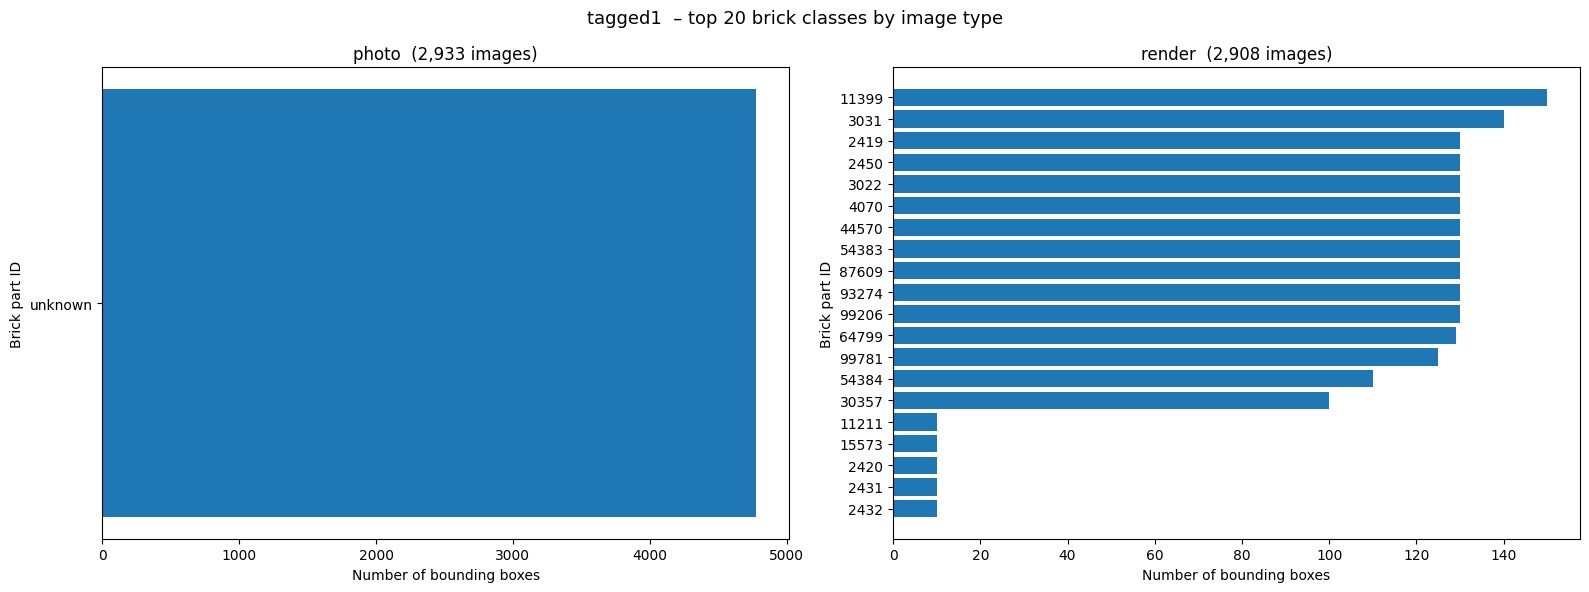

tagged1: 115 unique part IDs  (62.2% boxes have no part ID)
  Most common: 11399  (150 boxes)



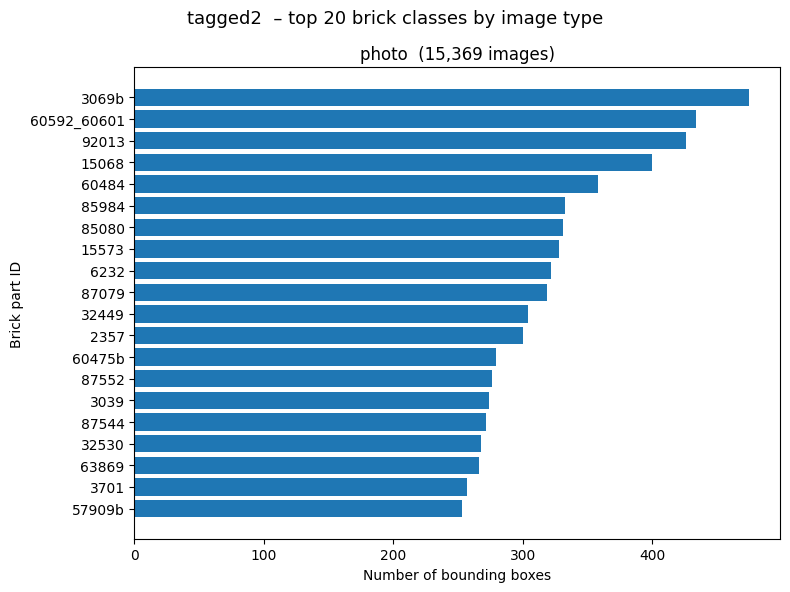

tagged2: 430 unique part IDs  (0.0% boxes have no part ID)
  Most common: 3069b  (475 boxes)



In [7]:
TOP_N = 20

for name, df in dfs.items():
    known = df[df["part_id"] != "unknown"]
    unknown_pct = 100 * (df["part_id"] == "unknown").sum() / len(df)

    types = df["image_type"].unique()
    ncols = len(types)
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f"{name}  – top {TOP_N} brick classes by image type", fontsize=13)

    for ax, itype in zip(axes, types):
        sub = df[df["image_type"] == itype]
        counts = sub["part_id"].value_counts().head(TOP_N)
        ax.barh(counts.index[::-1], counts.values[::-1])
        ax.set_title(f"{itype}  ({sub['filename'].nunique():,} images)")
        ax.set_xlabel("Number of bounding boxes")
        ax.set_ylabel("Brick part ID")

    plt.tight_layout()
    plt.show()

    print(f"{name}: {df['part_id'].nunique()} unique part IDs  "
          f"({unknown_pct:.1f}% boxes have no part ID)")
    if len(known):
        top = known["part_id"].value_counts().iloc[0]
        top_id = known["part_id"].value_counts().index[0]
        print(f"  Most common: {top_id}  ({top:,} boxes)")
    print()

## 6 · Bounding-Box Size Distribution

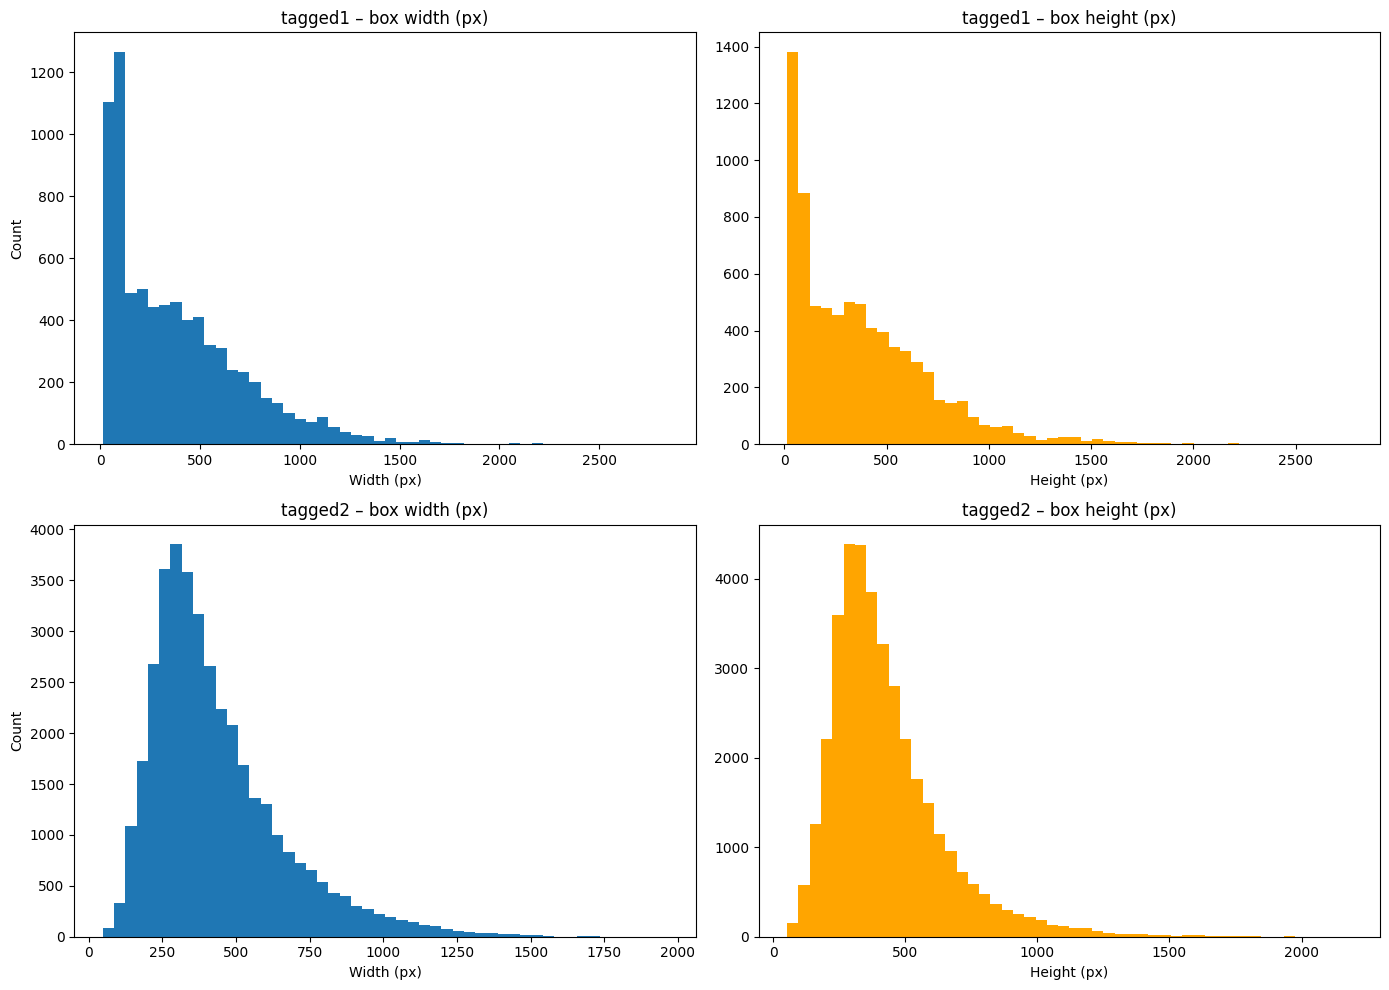


tagged1 – bounding-box statistics:
        box_w   box_h   box_area  aspect_ratio
count  7688.0  7688.0     7688.0        7688.0
mean    383.5   377.3   236648.0           1.1
std     339.5   332.9   392893.6           0.5
min      12.0    14.0      192.0           0.1
25%     100.0   101.0     9996.0           0.9
50%     302.0   307.0    96003.0           1.0
75%     565.0   555.0   313386.5           1.3
max    2842.0  2774.0  5805982.0           9.3

tagged2 – bounding-box statistics:
         box_w    box_h   box_area  aspect_ratio
count  37905.0  37905.0    37905.0       37905.0
mean     435.0    427.6   214714.2           1.1
std      226.6    215.6   218932.7           0.5
min       47.0     53.0     5781.0           0.1
25%      277.0    284.0    83782.0           0.8
50%      377.0    378.0   143899.0           1.0
75%      537.0    518.0   262359.0           1.2
max     1964.0   2190.0  2848983.0           8.7


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (name, df) in enumerate(dfs.items()):
    # Width distribution
    axes[row, 0].hist(df["box_w"], bins=50, edgecolor="none")
    axes[row, 0].set_title(f"{name} – box width (px)")
    axes[row, 0].set_xlabel("Width (px)")
    axes[row, 0].set_ylabel("Count")

    # Height distribution
    axes[row, 1].hist(df["box_h"], bins=50, edgecolor="none", color="orange")
    axes[row, 1].set_title(f"{name} – box height (px)")
    axes[row, 1].set_xlabel("Height (px)")

plt.tight_layout()
plt.show()

# Aspect ratio & area summary
for name, df in dfs.items():
    df = df.copy()
    df["aspect_ratio"] = df["box_w"] / df["box_h"].replace(0, np.nan)
    print(f"\n{name} – bounding-box statistics:")
    print(df[["box_w", "box_h", "box_area", "aspect_ratio"]].describe().round(1))

## 7 · Boxes per Image Distribution

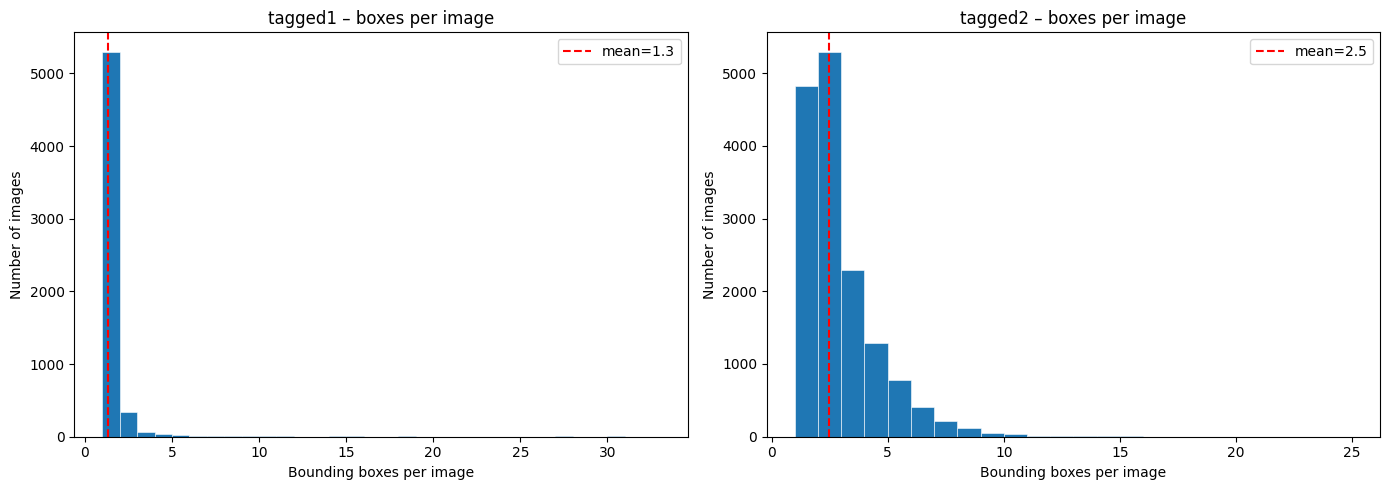

tagged1: min=1, median=1, mean=1.3, max=32
tagged2: min=1, median=2, mean=2.5, max=24


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    boxes_per_img = df.groupby("filename").size()
    ax.hist(boxes_per_img, bins=range(1, boxes_per_img.max() + 2), edgecolor="white", linewidth=0.4)
    ax.set_title(f"{name} – boxes per image")
    ax.set_xlabel("Bounding boxes per image")
    ax.set_ylabel("Number of images")
    ax.axvline(boxes_per_img.mean(), color="red", linestyle="--",
               label=f"mean={boxes_per_img.mean():.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

for name, df in dfs.items():
    bpi = df.groupby("filename").size()
    print(f"{name}: min={bpi.min()}, median={bpi.median():.0f}, "
          f"mean={bpi.mean():.1f}, max={bpi.max()}")

## 8 · Sample Images with Bounding Boxes

Show 4 random images from each dataset with all annotations drawn on top.

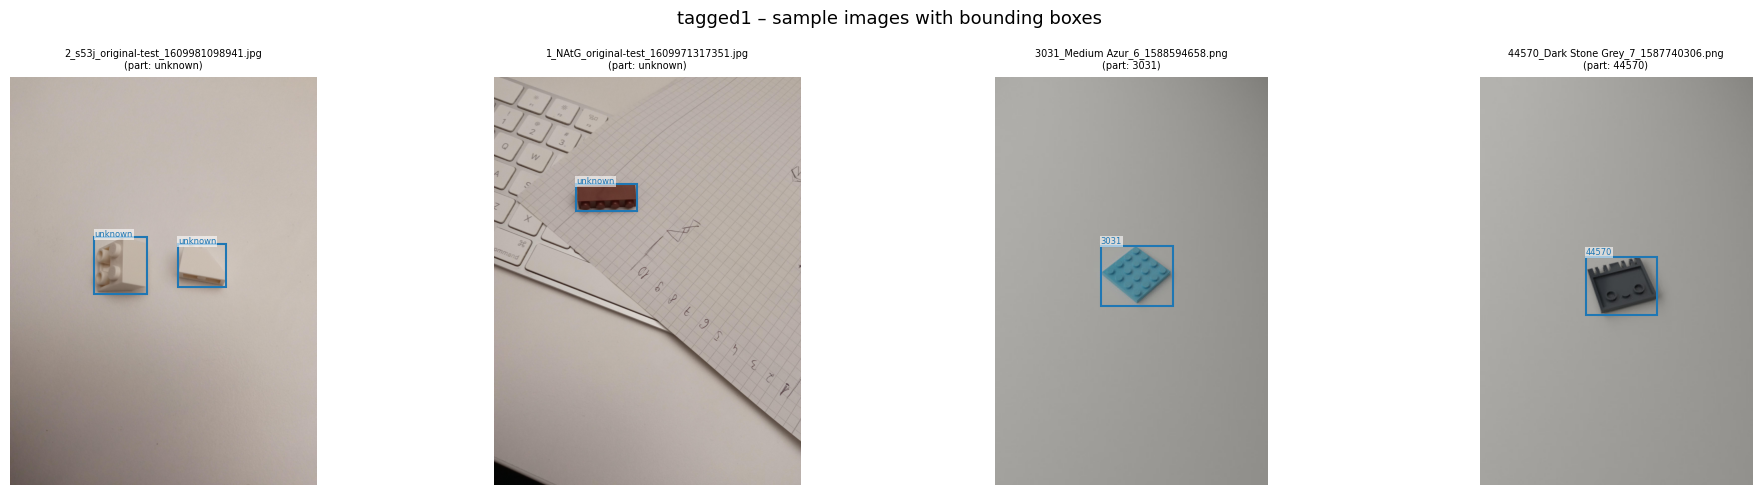

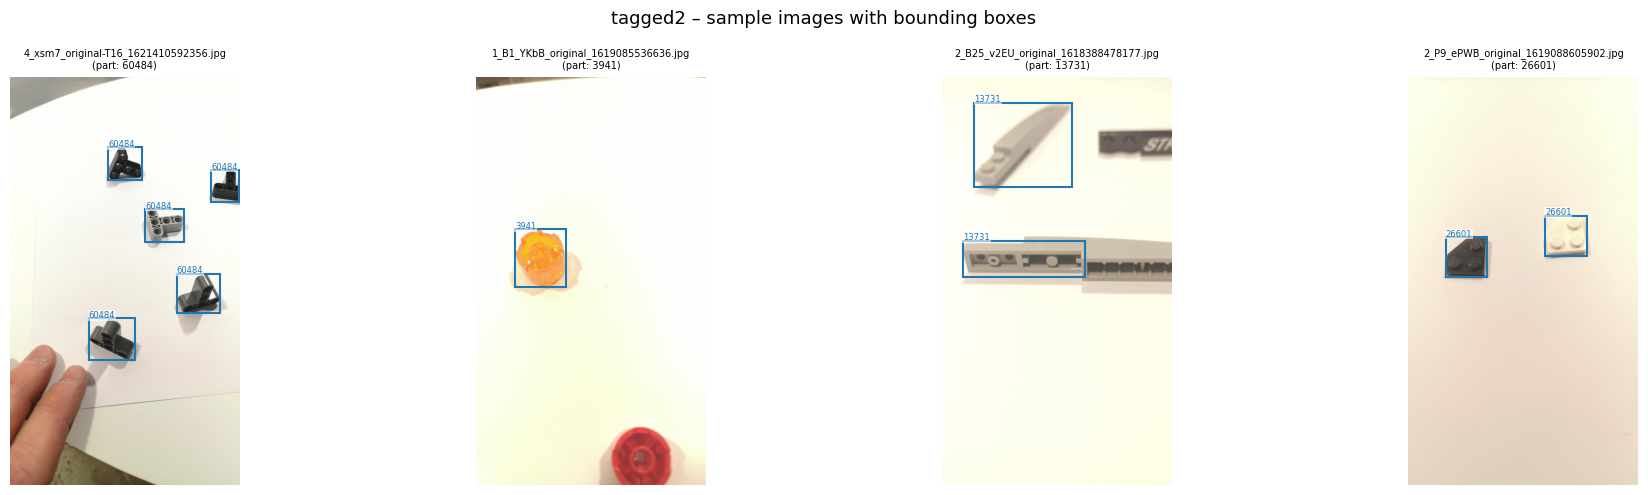

In [10]:
rng = np.random.default_rng(42)
SAMPLES = 4

for name, df in dfs.items():
    # Only pick images that have an img_path (found on disk)
    candidates_df = df.dropna(subset=["img_path"])
    candidates = candidates_df["filename"].unique()
    chosen = rng.choice(candidates, size=min(SAMPLES, len(candidates)), replace=False)

    fig, axes = plt.subplots(1, len(chosen), figsize=(5 * len(chosen), 5))
    if len(chosen) == 1:
        axes = [axes]
    fig.suptitle(f"{name} – sample images with bounding boxes", fontsize=13)

    for ax, fname in zip(axes, chosen):
        rows = df[df["filename"] == fname]
        img_path = rows["img_path"].dropna().iloc[0] if not rows["img_path"].dropna().empty else None

        if img_path is None:
            ax.set_title(f"{fname}\n(image not found)")
            ax.axis("off")
            continue

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        part = rows["part_id"].iloc[0]
        ax.set_title(f"{pathlib.Path(fname).name}\n(part: {part})", fontsize=7)
        ax.axis("off")

        cmap = plt.colormaps["tab20"]
        parts = rows["part_id"].unique()
        part_color = {p: cmap(i / max(len(parts) - 1, 1)) for i, p in enumerate(parts)}

        for _, r in rows.iterrows():
            rect = patches.Rectangle(
                (r["xmin"], r["ymin"]), r["box_w"], r["box_h"],
                linewidth=1.5, edgecolor=part_color[r["part_id"]], facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(r["xmin"], r["ymin"] - 3, r["part_id"],
                    fontsize=6, color=part_color[r["part_id"]],
                    bbox=dict(boxstyle="square,pad=0.1", fc="white", alpha=0.6, lw=0))

    plt.tight_layout()
    plt.show()